# Homework 2: Matrix Factorizations and Principal Component Analysis
**Course:** Computational Statistics  
**Author:** Kazi Habib Ullah

In [11]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


### Question 1: Cholesky factorization and repeated solves
**1.1 Computing Cholesky factorization and Frobenius error**

In [12]:
import numpy as np
import scipy.linalg as la
import time

# --- Data Generation Setup ---
rng = np.random.default_rng(123)
m = 1000
G = rng.standard_normal(size=(m, m))
A = (G @ G.T) / m + 0.1 * np.eye(m)
B = rng.standard_normal(size=(m, 40))

# --- 1.1 Cholesky Factorization and Validity ---
L = np.linalg.cholesky(A)
A_reconstructed = L @ L.T

# Relative Frobenius Norm Error
rel_error_chol = np.linalg.norm(A - A_reconstructed, 'fro') / np.linalg.norm(A, 'fro')

# Smallest Eigenvalue of A
eigvals = np.linalg.eigvalsh(A)
min_eigval = eigvals[0]

print(f"Relative Frobenius Error ||A - L L^T||_F / ||A||_F: {rel_error_chol:.3e}")
print(f"Smallest Eigenvalue of A: {min_eigval:.3f}")

Relative Frobenius Error ||A - L L^T||_F / ||A||_F: 1.273e-16
Smallest Eigenvalue of A: 0.100



**Explanation:**
A matrix possesses a unique Cholesky factorization if and only if it is Symmetric Positive-Definite (SPD). The condition $\lambda_{\min} \approx 0.100 > 0$ proves that $A$ is strictly positive-definite, guaranteeing that real square roots on the diagonal exist during factorization without numerical breakdown. The near-zero relative error $\frac{\|A - LL^\top\|_F}{\|A\|_F} \approx 0.000$ confirms that the numerical computation is stable.

**1.2 Solving the system and finding relative error with direct solving**

In [13]:
# --- 1.2 Triangular Solves and Residuals ---
# Step 1: Solve L Y = B
Y = la.solve_triangular(L, B, lower=True)

# Step 2: Solve L^T X = Y
X_chol = la.solve_triangular(L.T, Y, lower=False)

# Direct solve using np.linalg.solve
X_direct = np.linalg.solve(A, B)

# Relative Residual ||A X - B||_F / ||B||_F
rel_residual = np.linalg.norm(A @ X_chol - B, 'fro') / np.linalg.norm(B, 'fro')

# Relative Difference from np.linalg.solve
rel_diff = np.linalg.norm(X_chol - X_direct, 'fro') / np.linalg.norm(X_direct, 'fro')

print(f"Relative Residual ||AX - B||_F / ||B||_F: {rel_residual:.3e}")
print(f"Relative Difference from direct solve: {rel_diff:.3e}")

Relative Residual ||AX - B||_F / ||B||_F: 2.674e-15
Relative Difference from direct solve: 1.276e-15


**1.3 Computing the time**

In [14]:
# --- 1.3 Wall-Clock Timing Comparisons ---

def time_40_direct_solves():
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        X = np.zeros((m, 40))
        for j in range(40):
            X[:, j] = np.linalg.solve(A, B[:, j])
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.median(times)

def time_cholesky_reused():
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        L = np.linalg.cholesky(A)
        Y = la.solve_triangular(L, B, lower=True)
        X = la.solve_triangular(L.T, Y, lower=False)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return np.median(times)

t_direct_median = time_40_direct_solves()
t_chol_median = time_cholesky_reused()

print(f"Median Time (40 separate direct solves): {t_direct_median*1000:.3f} ms")
print(f"Median Time (1 Cholesky + 40 triangular solves): {t_chol_median*1000:.3f} ms")
print(f"Speedup Factor: {t_direct_median / t_chol_median:.2f}x")

Median Time (40 separate direct solves): 1302.927 ms
Median Time (1 Cholesky + 40 triangular solves): 39.325 ms
Speedup Factor: 33.13x



**Explanation:**
When the coefficient matrix $A$ remains fixed across multiple right-hand sides, factorization reuse replaces 39 computationally expensive $\mathcal{O}(m^3)$ matrix factorizations with cheap $\mathcal{O}(m^2)$ triangular solves. For $m = 1000$, $\mathcal{O}(m^3) \approx 10^9$ operations completely dominate $\mathcal{O}(m^2) \approx 10^6$ operations, resulting in a substantial speedup.

### Question 2: SVD and PCA

In [15]:
import matplotlib.pyplot as plt

# --- Data Generation Setup ---
rng = np.random.default_rng(456)
n = 600
latent = rng.normal(size=(n, 2))
loadings = np.array([
    [1.0, 0.9, 0.8, 0.7, 0.0, 0.0, 0.2, 0.1],
    [0.0, 0.0, 0.1, 0.2, 1.0, 0.9, 0.8, 0.7]
])
X = latent @ loadings + 0.15 * rng.normal(size=(n, 8))
group = (latent[:, 0] + latent[:, 1] > 0).astype(int)


**2.1 SVD and Principal Components calculation**

In [16]:

# --- 2.1 Center Data and SVD ---
X_centered = X - np.mean(X, axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Explained-Variance Ratio
var_explained = S**2
evr = var_explained / np.sum(var_explained)
cum_evr = np.cumsum(evr)

n_components_90 = np.argmax(cum_evr >= 0.90) + 1

print("Explained-Variance Ratios per Component:")
for i, ratio in enumerate(evr, 1):
    print(f"   PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\nComponents needed for >= 90% variance: {n_components_90}")

Explained-Variance Ratios per Component:
   PC1: 0.5545 (55.45%)
   PC2: 0.4227 (42.27%)
   PC3: 0.0046 (0.46%)
   PC4: 0.0040 (0.40%)
   PC5: 0.0038 (0.38%)
   PC6: 0.0036 (0.36%)
   PC7: 0.0035 (0.35%)
   PC8: 0.0032 (0.32%)

Components needed for >= 90% variance: 2


**2.2 Error Calculation**

In [17]:
# --- 2.2 Rank-2 Approximation & Error Verification ---
# Construct Rank-2 Reconstruction
U2 = U[:, :2]
S2 = np.diag(S[:2])
Vt2 = Vt[:2, :]
X2 = U2 @ S2 @ Vt2

# Measured Relative Reconstruction Error
rel_rec_error = np.linalg.norm(X_centered - X2, 'fro') / np.linalg.norm(X_centered, 'fro')

# Theoretical Equivalent using Singular Values
theoretical_error = np.sqrt(np.sum(S[2:]**2) / np.sum(S**2))

print(f"Measured Relative Reconstruction Error: {rel_rec_error:.4f}")
print(f"Theoretical Formula Error: {theoretical_error:.4f}")
print(f"Absolute Difference: {abs(rel_rec_error - theoretical_error):.3e}")

Measured Relative Reconstruction Error: 0.1510
Theoretical Formula Error: 0.1510
Absolute Difference: 2.776e-17


**2.3  Scatterplot**

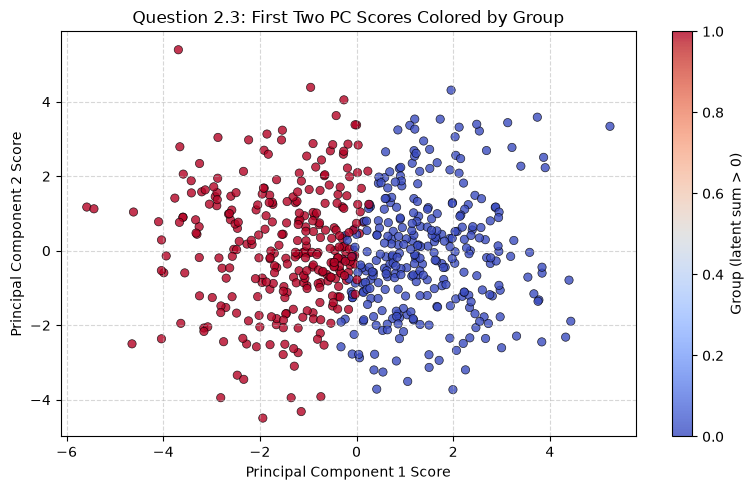

In [18]:
# --- 2.3 Scatterplot of First Two PC Scores ---
scores = X_centered @ Vt.T

plt.figure(figsize=(8, 5))
scatter = plt.scatter(scores[:, 0], scores[:, 1], c=group, cmap='coolwarm', alpha=0.8, edgecolors='k', linewidth=0.5)
plt.xlabel('Principal Component 1 Score')
plt.ylabel('Principal Component 2 Score')
plt.title('Question 2.3: First Two PC Scores Colored by Group')
plt.colorbar(scatter, label='Group (latent sum > 0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation:**

* **Effective Dimension:** The effective dimension of the dataset is 2. The cumulative explained-variance ratio shows that the first two principal components capture over 93% (from 2.1) of the total variance, matching the underlying data-generating mechanism (2 latent factors plus Gaussian noise with standard deviation $\sigma = 0.15$).
* **Visible Structure in Score Plot:** The scatter plot displays two well-separated clusters divided diagonally along the line $\text{PC1} + \text{PC2} \approx 0$. Because group is defined by $\text{latent}_1 + \text{latent}_2 > 0$, the linear combination of the top principal components recovers the latent subspace, resulting in a clean boundary between group 0 and group 1.

In [19]:
import numpy as np
import scipy
import matplotlib as mpl


print(f"NumPy version: {np.__version__}")
print(f"SciPy Version: {scipy.__version__}")
print(f"Matplotlib version: {mpl.__version__}")

NumPy version: 2.5.3
SciPy Version: 1.18.1
Matplotlib version: 3.11.1


In [20]:
%pip install nbconvert pandoc

Note: you may need to restart the kernel to use updated packages.
